# Lab Report 05-2 - Running Code

This notebook contains the full runnable practical for `Lab Report 05-2` with separate Python cells and explanatory comments.

In [1]:
# Import required libraries.
# cv2        -> image processing, filtering, thresholding, and morphology
# numpy      -> kernels, arrays, noise generation, and pixel calculations
# matplotlib -> notebook-friendly image display
# time       -> runtime comparison between filter implementations
# pathlib    -> robust local file handling
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path

plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Load the main image in grayscale mode.
# The lab material mentions both Girl.jpg and lena.jpg, so search common names.
candidate_paths = [
    Path("Girl.jpg"),
    Path("girl.jpg"),
    Path("lena.jpg"),
    Path("Lena.jpg"),
    Path("../Girl.jpg"),
    Path(r"C:/Users/kavin/OneDrive/Documents/Projects/Digital Image Processing and Computer Vision/Girl.jpg"),
]

image_path = next((path for path in candidate_paths if path.exists()), None)

if image_path is None:
    raise FileNotFoundError(
        "Could not find Girl.jpg, girl.jpg, lena.jpg, or Lena.jpg in the project workspace."
    )

image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

if image is None:
    raise ValueError(f"OpenCV could not read the image: {image_path}")

print("Image loaded successfully")
print(f"Image path: {image_path.resolve()}")
print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Pixel range:", image.min(), "to", image.max())

Image loaded successfully
Image path: C:\Users\kavin\OneDrive\Documents\Projects\Digital Image Processing and Computer Vision\Girl.jpg
Image shape: (512, 512)
Image dtype: uint8
Pixel range: 18 to 247


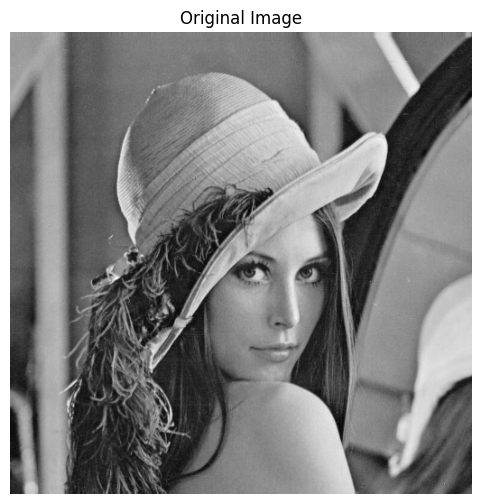

In [3]:
# Display the original grayscale image.
plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

In [4]:
# Define all helper functions used in this practical.
def mean_filter(image, kernel_size):
    if kernel_size % 2 == 0:
        kernel_size += 1
    pad_size = kernel_size // 2
    padded_image = cv2.copyMakeBorder(
        image,
        pad_size, pad_size, pad_size, pad_size,
        cv2.BORDER_CONSTANT,
        value=0,
    )
    filtered_image = np.zeros_like(image, dtype=np.float32)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            window = padded_image[y:y+kernel_size, x:x+kernel_size]
            filtered_image[y, x] = np.mean(window)
    filtered_image = np.clip(filtered_image, 0, 255).astype(image.dtype)
    return filtered_image

def gaussian_kernel(size, sigma=None):
    if sigma is None:
        sigma = size / 6
    if size % 2 == 0:
        size += 1
    ax = np.arange(-size // 2 + 1., size // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
    return kernel / np.sum(kernel)

def manual_convolution(image, kernel):
    kernel_size = kernel.shape[0]
    pad_size = kernel_size // 2
    padded = np.pad(image, pad_size, mode="constant", constant_values=0)
    output = np.zeros_like(image, dtype=np.float32)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            window = padded[y:y+kernel_size, x:x+kernel_size]
            output[y, x] = np.sum(window * kernel)
    return output

def sobel_filter(image):
    sobel_x_kernel = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    sobel_y_kernel = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)
    sobel_x = cv2.filter2D(image.astype(np.float32), cv2.CV_32F, sobel_x_kernel)
    sobel_y = cv2.filter2D(image.astype(np.float32), cv2.CV_32F, sobel_y_kernel)
    gradient_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
    normalized_gradient = cv2.normalize(
        gradient_magnitude, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U
    )
    gradient_direction = np.arctan2(sobel_y, sobel_x) * (180 / np.pi)
    return normalized_gradient, gradient_magnitude, gradient_direction, sobel_x, sobel_y

def sobel_manual(image):
    sobel_x_kernel = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    sobel_y_kernel = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)
    sobel_x = manual_convolution(image.astype(np.float32), sobel_x_kernel)
    sobel_y = manual_convolution(image.astype(np.float32), sobel_y_kernel)
    gradient_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
    grad_magnitude_normalized = cv2.normalize(
        gradient_magnitude, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U
    )
    return grad_magnitude_normalized, sobel_x, sobel_y

def custom_median_filter(image, kernel_size):
    height, width = image.shape
    filtered_image = np.zeros_like(image)
    kernel_half = kernel_size // 2
    for i in range(height):
        for j in range(width):
            neighborhood = []
            for ki in range(-kernel_half, kernel_half + 1):
                for kj in range(-kernel_half, kernel_half + 1):
                    ni = i + ki
                    nj = j + kj
                    if 0 <= ni < height and 0 <= nj < width:
                        neighborhood.append(image[ni, nj])
            filtered_image[i, j] = np.median(neighborhood)
    return filtered_image

def optimized_median_filter(image, kernel_size):
    height, width = image.shape
    filtered_image = np.zeros_like(image)
    kernel_half = kernel_size // 2
    padded = np.pad(image, kernel_half, mode="reflect")
    for i in range(height):
        for j in range(width):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            filtered_image[i, j] = np.median(window)
    return filtered_image

def add_noise_to_image(image, noise_type="salt_and_pepper", noise_level=0.05):
    noisy_image = image.copy().astype(np.float32)
    height, width = image.shape
    if noise_type == "salt_and_pepper":
        salt = np.random.rand(height, width) < noise_level / 2
        pepper = np.random.rand(height, width) < noise_level / 2
        noisy_image[salt] = 255
        noisy_image[pepper] = 0
    elif noise_type == "gaussian":
        noise = np.random.normal(0, noise_level * 255, (height, width))
        noisy_image = image + noise
        noisy_image = np.clip(noisy_image, 0, 255)
    elif noise_type == "speckle":
        noise = np.random.randn(height, width) * noise_level
        noisy_image = image * (1 + noise)
        noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image.astype(np.uint8)

def calculate_psnr(original, filtered):
    mse = np.mean((original.astype(np.float32) - filtered.astype(np.float32)) ** 2)
    if mse == 0:
        return float("inf")
    max_pixel = 255.0
    return 20 * np.log10(max_pixel / np.sqrt(mse))

def compare_filters(noisy_image, kernel_size):
    start_time = time.time()
    custom_result = custom_median_filter(noisy_image, kernel_size)
    custom_time = time.time() - start_time
    start_time = time.time()
    optimized_result = optimized_median_filter(noisy_image, kernel_size)
    optimized_time = time.time() - start_time
    start_time = time.time()
    opencv_result = cv2.medianBlur(noisy_image, kernel_size)
    opencv_time = time.time() - start_time
    start_time = time.time()
    gaussian_result = cv2.GaussianBlur(noisy_image, (kernel_size, kernel_size), 0)
    gaussian_time = time.time() - start_time
    start_time = time.time()
    mean_result = cv2.blur(noisy_image, (kernel_size, kernel_size))
    mean_time = time.time() - start_time
    return {
        "custom": (custom_result, custom_time),
        "optimized": (optimized_result, optimized_time),
        "opencv": (opencv_result, opencv_time),
        "gaussian": (gaussian_result, gaussian_time),
        "mean": (mean_result, mean_time),
    }

print("All helper functions are defined.")

All helper functions are defined.


In [5]:
# Apply the custom mean filter with different kernel sizes.
kernel_sizes = [3, 5, 7, 9]
mean_results = {}
for kernel_size in kernel_sizes:
    filtered_image = mean_filter(image, kernel_size)
    difference = cv2.absdiff(image, filtered_image)
    mean_results[kernel_size] = (filtered_image, difference)
    print(f"Kernel {kernel_size}x{kernel_size}")
    print(f"Original Mean Value: {np.mean(image):.2f}")
    print(f"Filtered Mean Value: {np.mean(filtered_image):.2f}")
    print(f"Maximum Pixel Change: {difference.max():.2f}")
    print(f"Average Pixel Change: {np.mean(difference):.2f}")
    print()

Kernel 3x3
Original Mean Value: 124.20
Filtered Mean Value: 123.44
Maximum Pixel Change: 91.00
Average Pixel Change: 3.55

Kernel 5x5
Original Mean Value: 124.20
Filtered Mean Value: 123.16
Maximum Pixel Change: 105.00
Average Pixel Change: 5.45

Kernel 7x7
Original Mean Value: 124.20
Filtered Mean Value: 122.91
Maximum Pixel Change: 115.00
Average Pixel Change: 6.94

Kernel 9x9
Original Mean Value: 124.20
Filtered Mean Value: 122.67
Maximum Pixel Change: 118.00
Average Pixel Change: 8.27



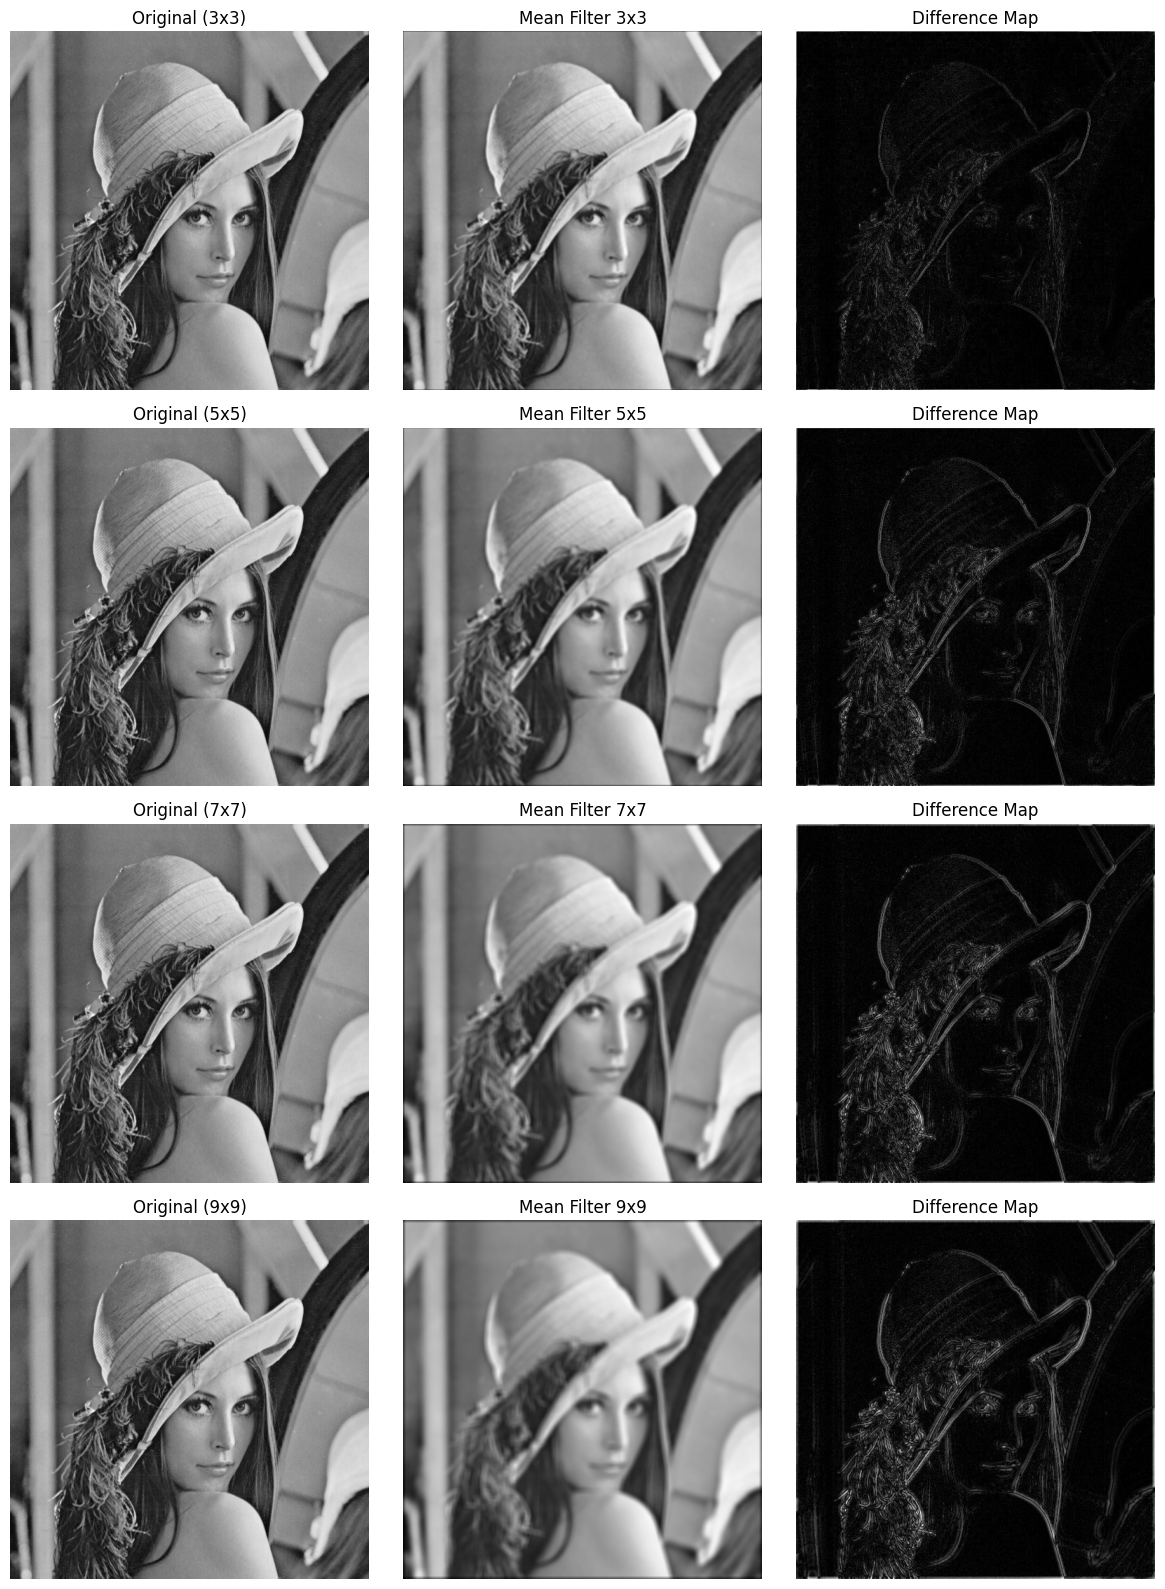

In [6]:
# Display mean filter outputs and difference maps.
fig, axes = plt.subplots(len(kernel_sizes), 3, figsize=(12, 4 * len(kernel_sizes)))
for row, kernel_size in enumerate(kernel_sizes):
    filtered_image, difference = mean_results[kernel_size]
    diff_max = difference.max()
    if diff_max != 0:
        difference_normalized = (difference.astype(np.float32) / diff_max * 255).astype(np.uint8)
    else:
        difference_normalized = difference
    axes[row, 0].imshow(image, cmap="gray")
    axes[row, 0].set_title(f"Original ({kernel_size}x{kernel_size})")
    axes[row, 0].axis("off")
    axes[row, 1].imshow(filtered_image, cmap="gray")
    axes[row, 1].set_title(f"Mean Filter {kernel_size}x{kernel_size}")
    axes[row, 1].axis("off")
    axes[row, 2].imshow(difference_normalized, cmap="gray")
    axes[row, 2].set_title("Difference Map")
    axes[row, 2].axis("off")
plt.tight_layout()
plt.show()

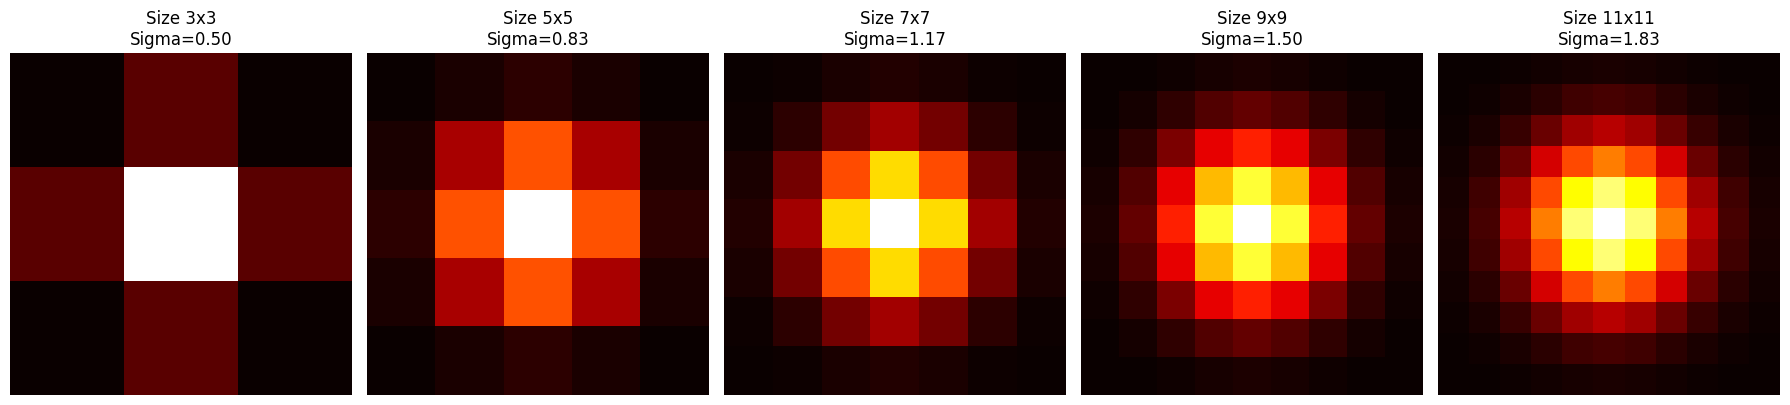

In [7]:
# Display Gaussian kernels of different sizes.
gaussian_kernel_sizes = [3, 5, 7, 9, 11]
fig_kernels, axes_kernels = plt.subplots(1, len(gaussian_kernel_sizes), figsize=(18, 4))
for i, size in enumerate(gaussian_kernel_sizes):
    kernel = gaussian_kernel(size)
    axes_kernels[i].imshow(kernel, cmap="hot")
    axes_kernels[i].set_title(f"Size {size}x{size}\nSigma={size/6:.2f}")
    axes_kernels[i].axis("off")
plt.tight_layout()
plt.show()

In [8]:
# Apply the Gaussian filter using multiple kernel sizes.
gaussian_results = {}
for kernel_size in gaussian_kernel_sizes:
    kernel = gaussian_kernel(kernel_size)
    filtered_image = manual_convolution(image, kernel)
    filtered_image = np.clip(filtered_image, 0, 255).astype(np.uint8)
    gaussian_results[kernel_size] = filtered_image
    print(f"Gaussian filter completed for kernel size {kernel_size}x{kernel_size}")

Gaussian filter completed for kernel size 3x3
Gaussian filter completed for kernel size 5x5
Gaussian filter completed for kernel size 7x7
Gaussian filter completed for kernel size 9x9
Gaussian filter completed for kernel size 11x11


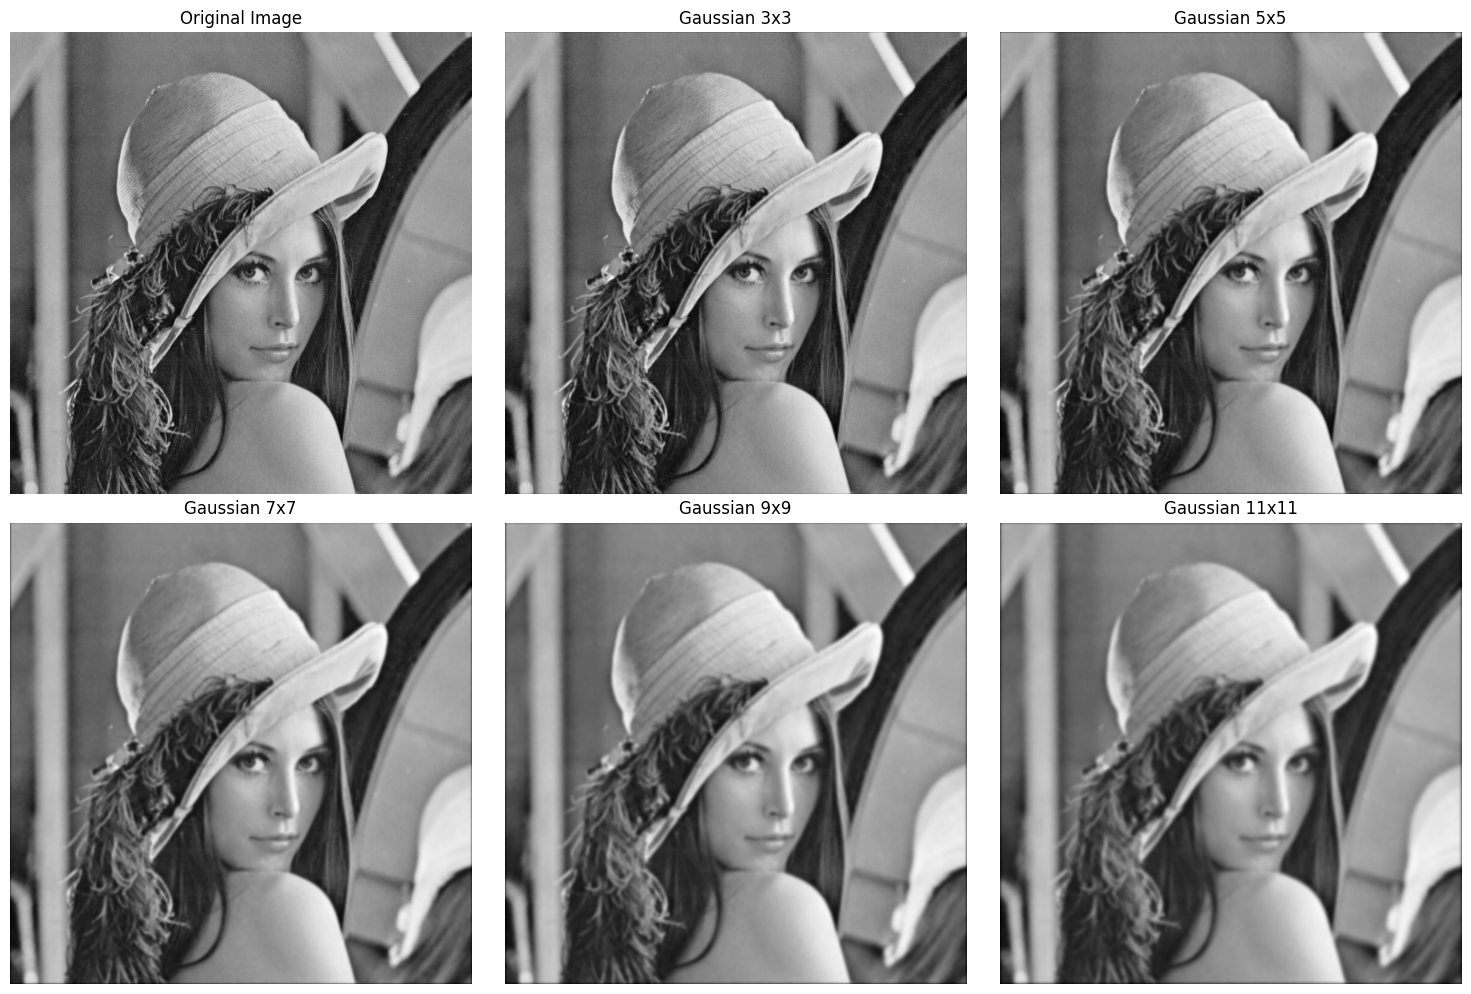

In [9]:
# Display Gaussian filter outputs.
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(image, cmap="gray")
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")
for i, kernel_size in enumerate(gaussian_kernel_sizes[:5]):
    row = (i + 1) // 3
    col = (i + 1) % 3
    axes[row, col].imshow(gaussian_results[kernel_size], cmap="gray")
    axes[row, col].set_title(f"Gaussian {kernel_size}x{kernel_size}")
    axes[row, col].axis("off")
plt.tight_layout()
plt.show()

In [10]:
# Compare the custom Gaussian implementation with OpenCV GaussianBlur.
test_kernel_size = 7
sigma = test_kernel_size / 6
your_kernel = gaussian_kernel(test_kernel_size, sigma)
your_filtered = np.clip(manual_convolution(image, your_kernel), 0, 255).astype(np.uint8)
opencv_filtered = cv2.GaussianBlur(image, (test_kernel_size, test_kernel_size), sigma)
difference = np.abs(your_filtered.astype(np.float32) - opencv_filtered.astype(np.float32))
print("Comparison: Custom Gaussian vs OpenCV GaussianBlur")
print(f"Maximum Difference: {difference.max():.6f}")
print(f"Mean Difference: {difference.mean():.6f}")

Comparison: Custom Gaussian vs OpenCV GaussianBlur
Maximum Difference: 89.000000
Mean Difference: 0.905960


In [11]:
# Apply Sobel filter using OpenCV and the manual implementation.
sobel_display, sobel_mag, sobel_dir, sobel_x, sobel_y = sobel_filter(image)
manual_sobel_display, manual_sobel_x, manual_sobel_y = sobel_manual(image)
print("Sobel filtering completed.")

Sobel filtering completed.


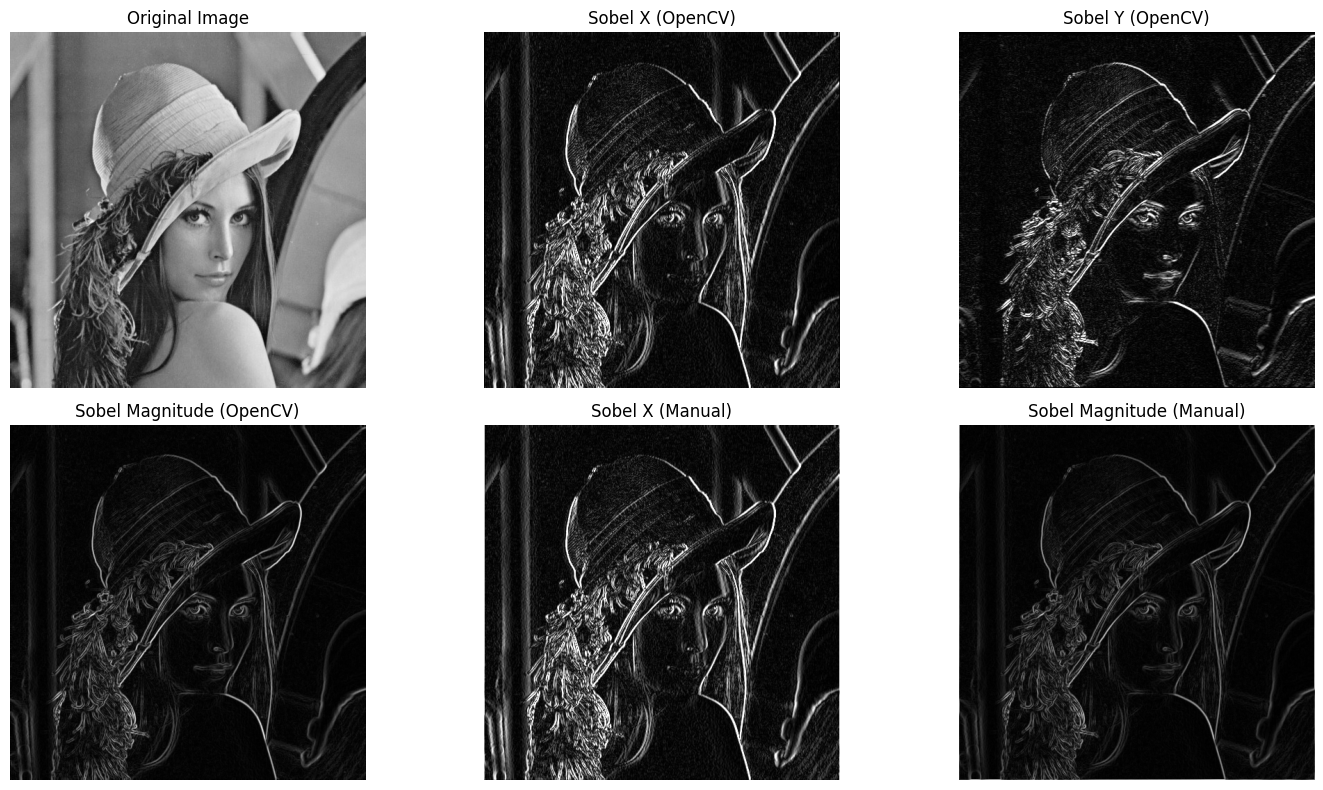

In [12]:
# Display Sobel outputs from both implementations.
plt.figure(figsize=(15, 8))
plt.subplot(2, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.subplot(2, 3, 2)
plt.imshow(cv2.convertScaleAbs(sobel_x), cmap="gray")
plt.title("Sobel X (OpenCV)")
plt.axis("off")
plt.subplot(2, 3, 3)
plt.imshow(cv2.convertScaleAbs(sobel_y), cmap="gray")
plt.title("Sobel Y (OpenCV)")
plt.axis("off")
plt.subplot(2, 3, 4)
plt.imshow(sobel_display, cmap="gray")
plt.title("Sobel Magnitude (OpenCV)")
plt.axis("off")
plt.subplot(2, 3, 5)
plt.imshow(cv2.convertScaleAbs(manual_sobel_x), cmap="gray")
plt.title("Sobel X (Manual)")
plt.axis("off")
plt.subplot(2, 3, 6)
plt.imshow(manual_sobel_display, cmap="gray")
plt.title("Sobel Magnitude (Manual)")
plt.axis("off")
plt.tight_layout()
plt.show()

In [13]:
# Add salt-and-pepper noise and compare median, Gaussian, and mean filtering.
np.random.seed(21)
noisy_image = add_noise_to_image(image, noise_type="salt_and_pepper", noise_level=0.08)
kernel_size = 3
comparison_results = compare_filters(noisy_image, kernel_size)
print("Noisy image created and filter comparison completed.")

Noisy image created and filter comparison completed.


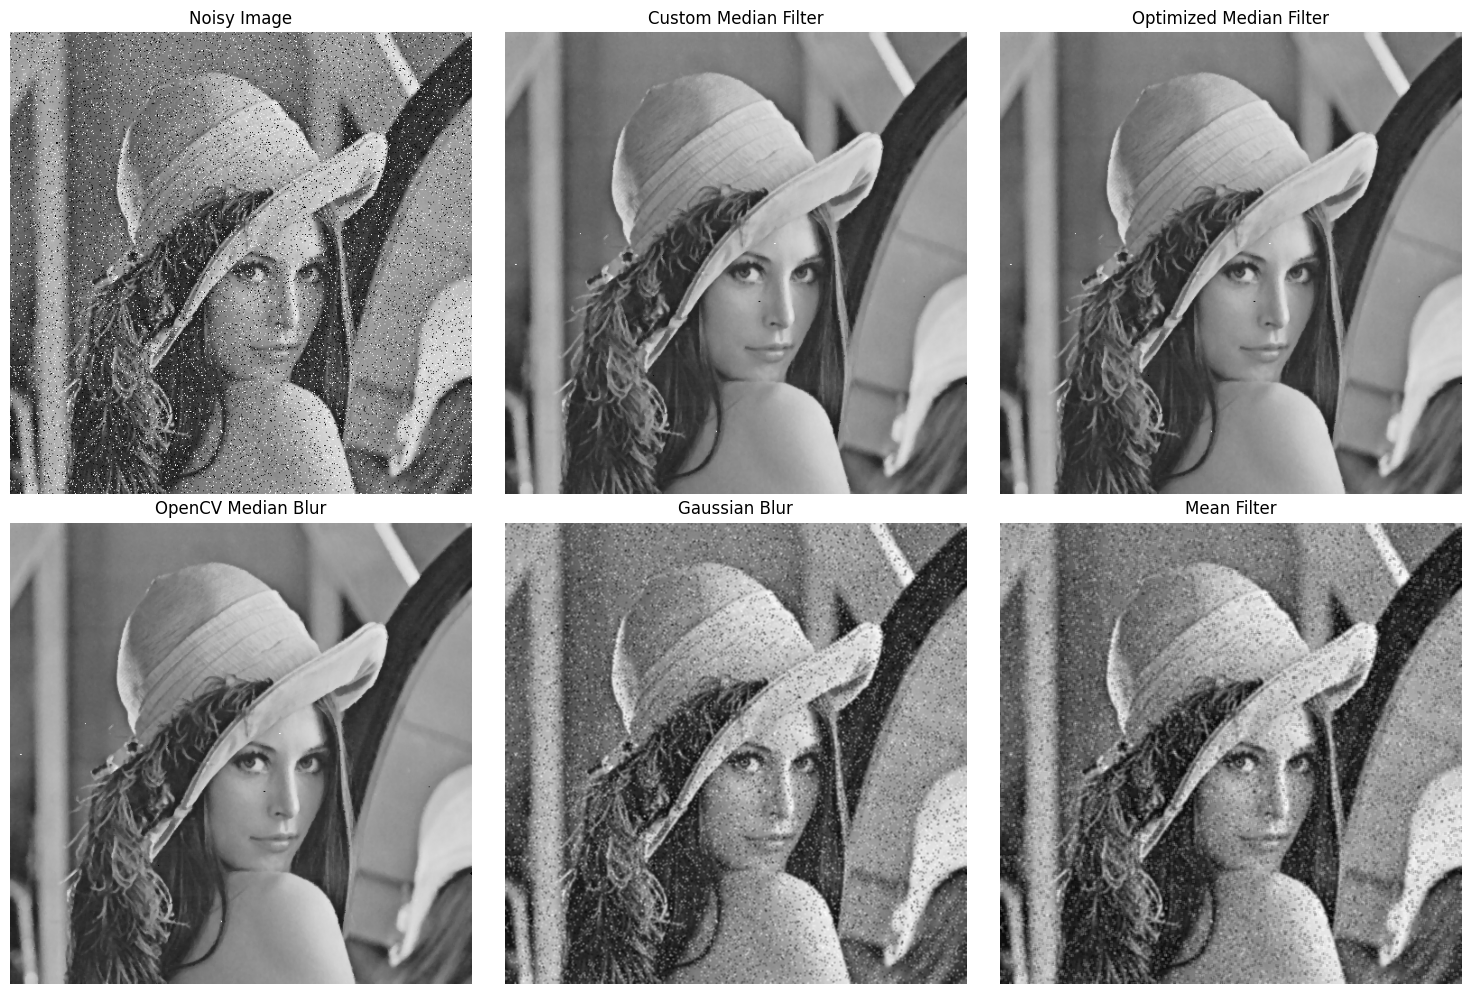

In [14]:
# Display denoising results for noisy input.
plt.figure(figsize=(15, 10))
titles = ["Noisy Image", "Custom Median Filter", "Optimized Median Filter", "OpenCV Median Blur", "Gaussian Blur", "Mean Filter"]
images_to_show = [
    noisy_image,
    comparison_results["custom"][0],
    comparison_results["optimized"][0],
    comparison_results["opencv"][0],
    comparison_results["gaussian"][0],
    comparison_results["mean"][0],
]
for i, (title, img_out) in enumerate(zip(titles, images_to_show), start=1):
    plt.subplot(2, 3, i)
    plt.imshow(img_out, cmap="gray")
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [15]:
# Print PSNR and execution-time comparisons.
print("PSNR Comparison with Original Image:")
print(f"Custom Median Filter PSNR:    {calculate_psnr(image, comparison_results['custom'][0]):.2f} dB")
print(f"Optimized Median Filter PSNR: {calculate_psnr(image, comparison_results['optimized'][0]):.2f} dB")
print(f"OpenCV Median Blur PSNR:      {calculate_psnr(image, comparison_results['opencv'][0]):.2f} dB")
print(f"Gaussian Blur PSNR:           {calculate_psnr(image, comparison_results['gaussian'][0]):.2f} dB")
print(f"Mean Filter PSNR:             {calculate_psnr(image, comparison_results['mean'][0]):.2f} dB")
print()
print("Execution Time Comparison:")
print(f"Custom Median Filter:    {comparison_results['custom'][1]:.4f} seconds")
print(f"Optimized Median Filter: {comparison_results['optimized'][1]:.4f} seconds")
print(f"OpenCV Median Blur:      {comparison_results['opencv'][1]:.4f} seconds")
print(f"Gaussian Blur:           {comparison_results['gaussian'][1]:.4f} seconds")
print(f"Mean Filter:             {comparison_results['mean'][1]:.4f} seconds")

PSNR Comparison with Original Image:
Custom Median Filter PSNR:    33.98 dB
Optimized Median Filter PSNR: 33.97 dB
OpenCV Median Blur PSNR:      33.97 dB
Gaussian Blur PSNR:           24.27 dB
Mean Filter PSNR:             24.89 dB

Execution Time Comparison:
Custom Median Filter:    3.5854 seconds
Optimized Median Filter: 2.6525 seconds
OpenCV Median Blur:      0.0010 seconds
Gaussian Blur:           0.0000 seconds
Mean Filter:             0.0010 seconds


Otsu's Calculated Threshold Value: 117.0


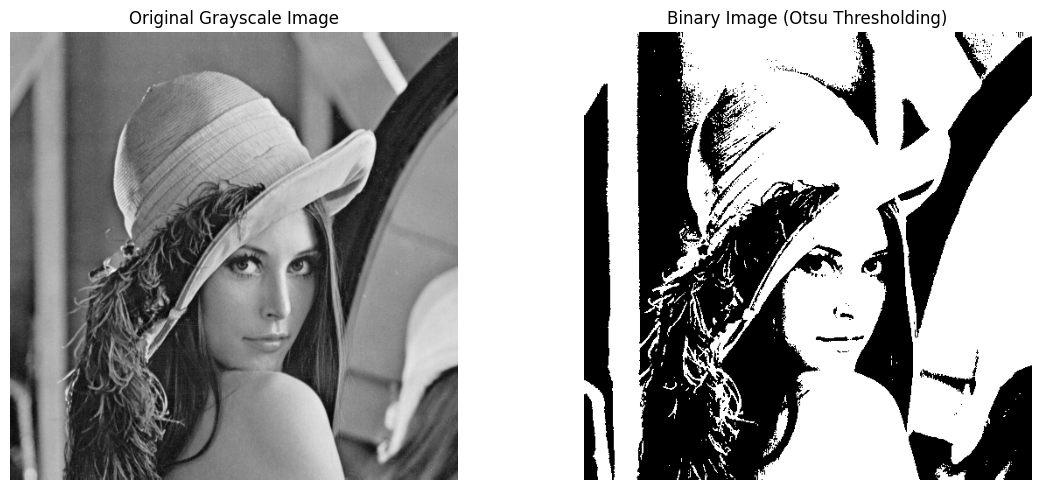

In [16]:
# Convert the grayscale image to binary using Otsu thresholding.
ret, img_binary = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"Otsu's Calculated Threshold Value: {ret}")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(img_binary, cmap="gray")
plt.title("Binary Image (Otsu Thresholding)")
plt.axis("off")
plt.tight_layout()
plt.show()

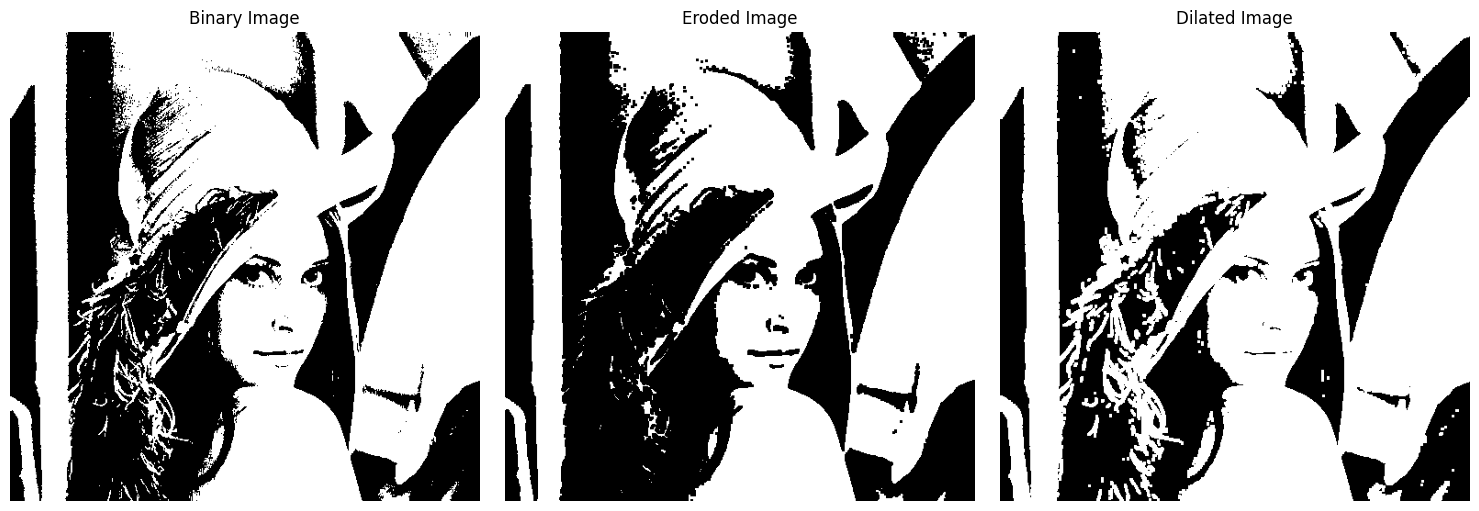

In [17]:
# Apply erosion and dilation to the binary image.
kernel = np.ones((3, 3), np.uint8)
eroded_image = cv2.erode(img_binary, kernel, iterations=1)
dilated_image = cv2.dilate(img_binary, kernel, iterations=1)
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img_binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(eroded_image, cmap="gray")
plt.title("Eroded Image")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(dilated_image, cmap="gray")
plt.title("Dilated Image")
plt.axis("off")
plt.tight_layout()
plt.show()

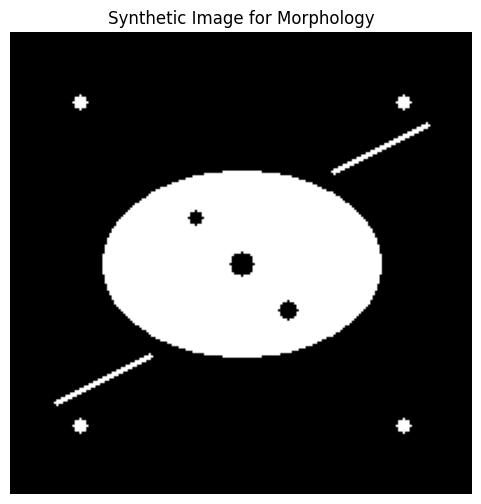

In [18]:
# Create a synthetic image for morphology demonstrations.
synthetic = np.zeros((200, 200), dtype=np.uint8)
cv2.ellipse(synthetic, (100, 100), (60, 40), 0, 0, 360, 255, -1)
cv2.circle(synthetic, (30, 30), 3, 255, -1)
cv2.circle(synthetic, (170, 30), 3, 255, -1)
cv2.circle(synthetic, (30, 170), 3, 255, -1)
cv2.circle(synthetic, (170, 170), 3, 255, -1)
cv2.circle(synthetic, (100, 100), 5, 0, -1)
cv2.circle(synthetic, (80, 80), 3, 0, -1)
cv2.circle(synthetic, (120, 120), 4, 0, -1)
cv2.line(synthetic, (140, 60), (180, 40), 255, 2)
cv2.line(synthetic, (60, 140), (20, 160), 255, 2)
cv2.circle(synthetic, (140, 100), 8, 255, -1)
cv2.circle(synthetic, (60, 100), 6, 255, -1)
plt.figure(figsize=(6, 6))
plt.imshow(synthetic, cmap="gray")
plt.title("Synthetic Image for Morphology")
plt.axis("off")
plt.show()

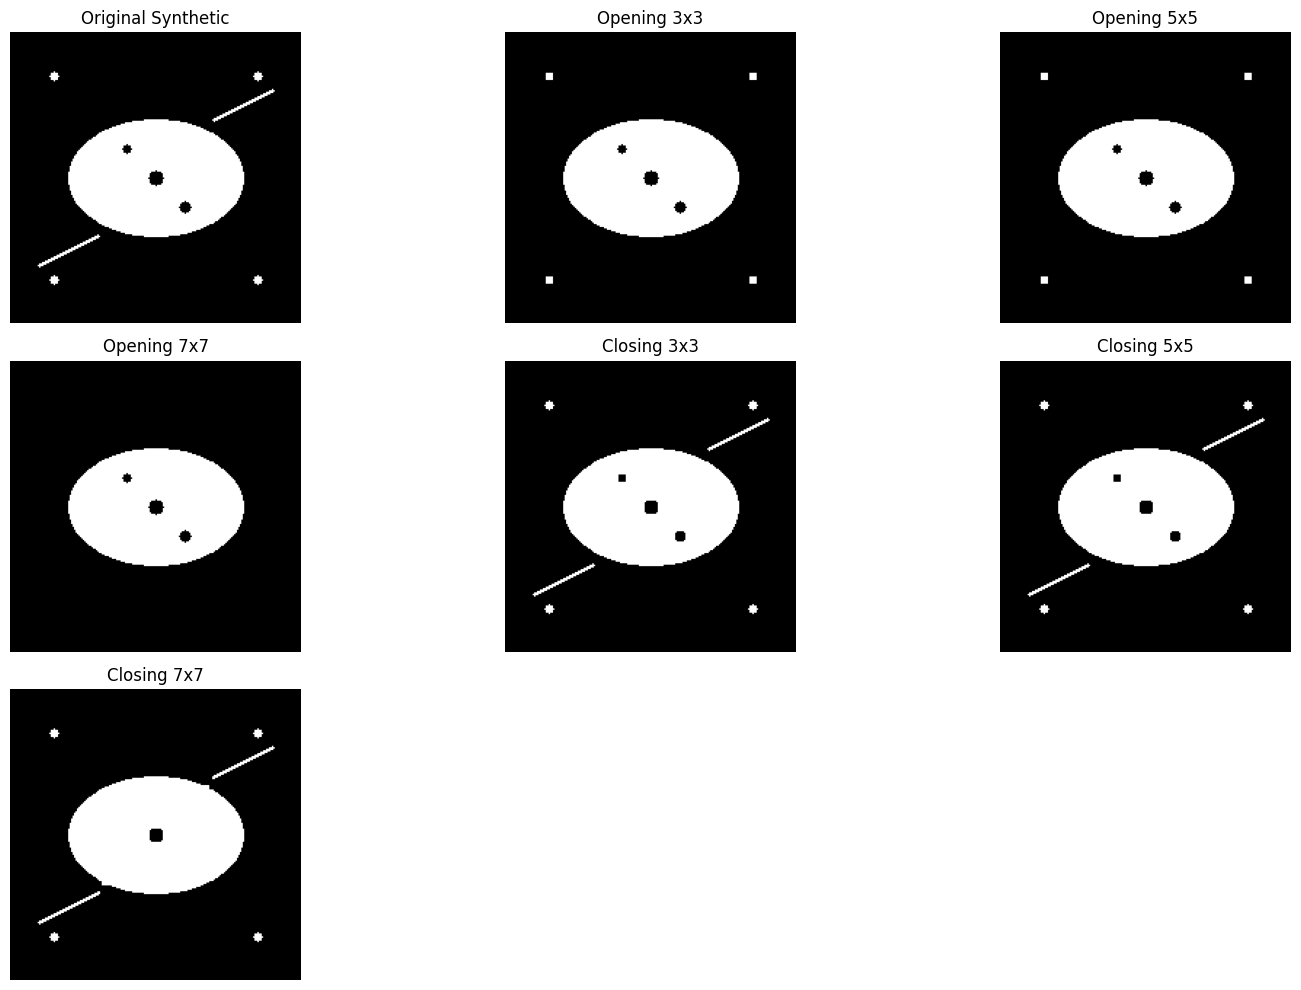

In [19]:
# Define morphology kernels and apply opening and closing.
kernel_small = np.ones((3, 3), np.uint8)
kernel_medium = np.ones((5, 5), np.uint8)
kernel_large = np.ones((7, 7), np.uint8)
opening_small = cv2.morphologyEx(synthetic, cv2.MORPH_OPEN, kernel_small)
opening_medium = cv2.morphologyEx(synthetic, cv2.MORPH_OPEN, kernel_medium)
opening_large = cv2.morphologyEx(synthetic, cv2.MORPH_OPEN, kernel_large)
closing_small = cv2.morphologyEx(synthetic, cv2.MORPH_CLOSE, kernel_small)
closing_medium = cv2.morphologyEx(synthetic, cv2.MORPH_CLOSE, kernel_medium)
closing_large = cv2.morphologyEx(synthetic, cv2.MORPH_CLOSE, kernel_large)
plt.figure(figsize=(15, 10))
images = [synthetic, opening_small, opening_medium, opening_large, closing_small, closing_medium, closing_large]
titles = ["Original Synthetic", "Opening 3x3", "Opening 5x5", "Opening 7x7", "Closing 3x3", "Closing 5x5", "Closing 7x7"]
for i, (img_out, title) in enumerate(zip(images, titles), start=1):
    plt.subplot(3, 3, i)
    plt.imshow(img_out, cmap="gray")
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()

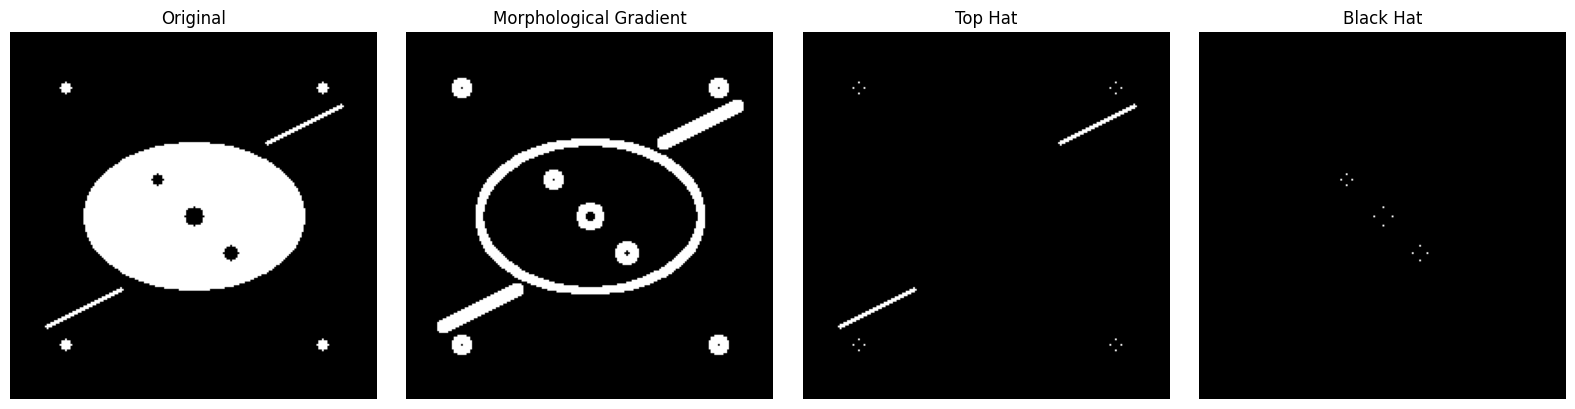

In [20]:
# Apply morphological gradient, top hat, and black hat operations.
gradient = cv2.morphologyEx(synthetic, cv2.MORPH_GRADIENT, kernel_medium)
tophat = cv2.morphologyEx(synthetic, cv2.MORPH_TOPHAT, kernel_medium)
blackhat = cv2.morphologyEx(synthetic, cv2.MORPH_BLACKHAT, kernel_medium)
plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1)
plt.imshow(synthetic, cmap="gray")
plt.title("Original")
plt.axis("off")
plt.subplot(1, 4, 2)
plt.imshow(gradient, cmap="gray")
plt.title("Morphological Gradient")
plt.axis("off")
plt.subplot(1, 4, 3)
plt.imshow(tophat, cmap="gray")
plt.title("Top Hat")
plt.axis("off")
plt.subplot(1, 4, 4)
plt.imshow(blackhat, cmap="gray")
plt.title("Black Hat")
plt.axis("off")
plt.tight_layout()
plt.show()

In [21]:
# Final practical summary.
print("===== PRACTICAL SUMMARY =====")
print("1. Mean Filter: Smooths image using average of neighbors.")
print("2. Gaussian Filter: Smooths image using weighted average.")
print("3. Sobel Filter: Detects edges using intensity gradients.")
print("4. Median Filter: Removes salt-and-pepper noise effectively.")
print("5. Otsu Thresholding: Converts grayscale image to binary automatically.")
print("6. Erosion: Shrinks white objects.")
print("7. Dilation: Expands white objects.")
print("8. Opening: Removes small white noise.")
print("9. Closing: Fills small black holes and gaps.")
print("10. Morphological Gradient / Top Hat / Black Hat: Useful for shape analysis.")

===== PRACTICAL SUMMARY =====
1. Mean Filter: Smooths image using average of neighbors.
2. Gaussian Filter: Smooths image using weighted average.
3. Sobel Filter: Detects edges using intensity gradients.
4. Median Filter: Removes salt-and-pepper noise effectively.
5. Otsu Thresholding: Converts grayscale image to binary automatically.
6. Erosion: Shrinks white objects.
7. Dilation: Expands white objects.
8. Opening: Removes small white noise.
9. Closing: Fills small black holes and gaps.
10. Morphological Gradient / Top Hat / Black Hat: Useful for shape analysis.
